In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv(r"C:\Users\Raaj Soni\Downloads\books.csv")
df

,title,category,price,rating,availability,description,upc,num_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,2,In stock (19 available)\n \n \n \n \...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,2,In stock (19 available)\n \n \n \n \...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,1,In stock (19 available)\n \n \n \n \...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,1,In stock (19 available)\n \n \n \n \...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,3,In stock (19 available)\n \n \n \n \...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...
...,...,...,...,...,...,...,...,...,...
95,In Her Wake,Thriller,£12.84,1,In stock (19 available)\n \n \n \n \...,A perfect life … until she discovered it wasn’...,23356462d1320d61,0,https://books.toscrape.com/catalogue/in-her-wa...
96,Sharp Objects,Mystery,£47.82,4,In stock (20 available)\n \n \n \n \...,"WICKED above her hipbone, GIRL across her hear...",e00eb4fd7b871a48,0,https://books.toscrape.com/catalogue/sharp-obj...
97,Soumission,Fiction,£50.10,1,In stock (20 available)\n \n \n \n \...,"Dans une France assez proche de la nôtre, un h...",6957f44c3847a760,0,https://books.toscrape.com/catalogue/soumissio...
98,Tipping the Velvet,Historical Fiction,£53.74,1,In stock (20 available)\n \n \n \n \...,"""Erotic and absorbing...Written with starling ...",90fa61229261140a,0,https://books.toscrape.com/catalogue/tipping-t...


In [3]:
import scrapy


class BookCatalogSpider(scrapy.Spider):
    name = "book_catalog"
    allowed_domains = ["books.toscrape.com"]
    start_urls = ["https://books.toscrape.com/"]

    rating_values = {
        "One": 1,
        "Two": 2,
        "Three": 3,
        "Four": 4,
        "Five": 5
    }

    max_pages = 5

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.catalog_count = 0

    def parse(self, response):
        """Collect book links from catalog pages."""

        self.catalog_count += 1

        book_links = response.css(
            "article.product_pod h3 a::attr(href)"
        ).getall()

        for link in book_links:
            yield response.follow(
                link,
                callback=self.extract_book
            )

        if self.catalog_count < self.max_pages:
            next_link = response.css(
                "li.next a::attr(href)"
            ).get()

            if next_link:
                yield response.follow(
                    next_link,
                    callback=self.parse
                )

    def extract_book(self, response):
        """Extract information from an individual book page."""

        book = BookItem()

        book["title"] = self.get_text(
            response.css("div.product_main h1::text").get()
        )

        book["price"] = self.get_text(
            response.css("p.price_color::text").get()
        )

        book["product_url"] = response.url

        book["category"] = self.extract_category(response)

        book["rating"] = self.extract_rating(response)

        book["availability"] = self.get_text(
            " ".join(
                response.css("p.availability::text").getall()
            )
        )

        book["description"] = self.get_text(
            response.css("#product_description ~ p::text").get()
        )

        product_info = self.extract_product_table(response)

        book["upc"] = product_info.get("UPC")
        book["num_reviews"] = product_info.get("Number of reviews")

        yield book

    @staticmethod
    def get_text(value):
        """Clean extracted text."""
        return value.strip() if value else ""

    def extract_category(self, response):
        """Get the book category from the breadcrumb."""

        crumbs = response.css(
            "ul.breadcrumb li a::text"
        ).getall()

        if len(crumbs) >= 2:
            return crumbs[-1].strip()

        return None

    def extract_rating(self, response):
        """Convert the star-rating class into a numeric value."""

        rating_classes = response.css(
            "p.star-rating::attr(class)"
        ).get(default="")

        for word, number in self.rating_values.items():
            if word in rating_classes:
                return number

        return None

    def extract_product_table(self, response):
        """Read UPC, reviews and other product information."""

        information = {}

        for row in response.css("table.table-striped tr"):
            field = row.css("th::text").get()
            value = row.css("td::text").get()

            if field and value:
                information[field.strip()] = value.strip()

        return information

Task 1 report - Total Records ,missing values , duplicates UPC'S

In [4]:
import json
import csv
import os
from collections import Counter


def read_data(filename):
    """Load scraped book records from JSON or CSV."""

    extension = os.path.splitext(filename)[1].lower()

    if extension == ".json":
        with open(filename, "r", encoding="utf-8") as file:
            return json.load(file)

    elif extension == ".csv":
        with open(filename, "r", encoding="utf-8", newline="") as file:
            reader = csv.DictReader(file)
            return list(reader)

    else:
        raise ValueError("Please provide a .json or .csv file.")


def generate_report(filename):
    """Check the scraped book data for missing values and duplicate UPCs."""

    records = read_data(filename)

    print("=" * 45)
    print("BOOK SCRAPING DATA REPORT")
    print("=" * 45)

    print(f"\nTotal scraped records: {len(records)}")

    fields_to_check = [
        "title",
        "category",
        "price",
        "rating",
        "availability",
        "description",
        "upc",
        "num_reviews",
        "product_url"
    ]

    # --- Check missing values ---
    print("\nMissing values per field:")

    for field_name in fields_to_check:
        missing_total = 0

        for record in records:
            value = record.get(field_name)

            if value is None or str(value).strip() == "":
                missing_total += 1

        print(f"{field_name:15} : {missing_total}")

    # --- Check duplicate UPC values ---
    print("\nDuplicate UPC check:")

    upc_list = []

    for record in records:
        current_upc = record.get("upc")

        if current_upc is not None and str(current_upc).strip():
            upc_list.append(str(current_upc).strip())

    upc_counts = Counter(upc_list)

    duplicate_upcs = {
        upc: count
        for upc, count in upc_counts.items()
        if count > 1
    }

    if duplicate_upcs:
        print(f"Found {len(duplicate_upcs)} duplicate UPC value(s):")

        for upc, count in duplicate_upcs.items():
            print(f"  {upc} -> {count} occurrences")
    else:
        print("No duplicate UPCs found.")

    print("\n" + "=" * 45)


# --- Location of the scraped CSV file ---
file_path = r"C:\Users\Raaj Soni\Downloads\books.csv"

# --- Check whether the file exists ---
if os.path.isfile(file_path):
    generate_report(file_path)
else:
    print("File not found:")
    print(file_path)

BOOK SCRAPING DATA REPORT

Total scraped records: 100

Missing values per field:
title           : 0
category        : 0
price           : 0
rating          : 0
availability    : 0
description     : 0
upc             : 0
num_reviews     : 0
product_url     : 0

Duplicate UPC check:
No duplicate UPCs found.



In [5]:
import json
import csv
import os
from collections import Counter


def read_data(filename):
    """Load scraped book records from JSON or CSV."""

    extension = os.path.splitext(filename)[1].lower()

    if extension == ".json":
        with open(filename, "r", encoding="utf-8") as file:
            return json.load(file)

    elif extension == ".csv":
        with open(filename, "r", encoding="utf-8", newline="") as file:
            reader = csv.DictReader(file)
            return list(reader)

    else:
        raise ValueError("Please provide a .json or .csv file.")


def generate_report(filename):
    """Check the scraped book data for missing values and duplicate UPCs."""

    records = read_data(filename)

    print("=" * 45)
    print("BOOK SCRAPING DATA REPORT")
    print("=" * 45)

    print(f"\nTotal scraped records: {len(records)}")

    fields_to_check = [
        "title",
        "category",
        "price",
        "rating",
        "availability",
        "description",
        "upc",
        "num_reviews",
        "product_url"
    ]

    # --- Check missing values ---
    print("\nMissing values per field:")

    for field_name in fields_to_check:
        missing_total = 0

        for record in records:
            value = record.get(field_name)

            if value is None or str(value).strip() == "":
                missing_total += 1

        print(f"{field_name:15} : {missing_total}")

    # --- Check duplicate UPC values ---
    print("\nDuplicate UPC check:")

    upc_list = []

    for record in records:
        current_upc = record.get("upc")

        if current_upc is not None and str(current_upc).strip():
            upc_list.append(str(current_upc).strip())

    upc_counts = Counter(upc_list)

    duplicate_upcs = {
        upc: count
        for upc, count in upc_counts.items()
        if count > 1
    }

    if duplicate_upcs:
        print(f"Found {len(duplicate_upcs)} duplicate UPC value(s):")

        for upc, count in duplicate_upcs.items():
            print(f"  {upc} -> {count} occurrences")
    else:
        print("No duplicate UPCs found.")

    print("\n" + "=" * 45)


# --- Location of the scraped CSV file ---
file_path = r"C:\Users\Raaj Soni\Downloads\books.csv"

# --- Check whether the file exists ---
if os.path.isfile(file_path):
    generate_report(file_path)
else:
    print("File not found:")
    print(file_path)

BOOK SCRAPING DATA REPORT

Total scraped records: 100

Missing values per field:
title           : 0
category        : 0
price           : 0
rating          : 0
availability    : 0
description     : 0
upc             : 0
num_reviews     : 0
product_url     : 0

Duplicate UPC check:
No duplicate UPCs found.



TASK 2 - DATA PREPROCSSEING 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_style("whitegrid")

In [7]:
import pandas as pd

# --- Load the raw scraped data from Task 1 ---
file_path = r"C:\Users\Raaj Soni\Downloads\books.csv"

df = pd.read_csv(file_path)

print(f"Raw records loaded: {len(df)}")
print("\nColumns in the dataset:")
print(df.columns.tolist())

Raw records loaded: 100

Columns in the dataset:
['title', 'category', 'price', 'rating', 'availability', 'description', 'upc', 'num_reviews', 'product_url']


In [29]:
# 1. Description word count
df["description_word_count"] = (
    df["description"]
    .fillna("")
    .str.split()
    .apply(len)
)

In [30]:
# 2. Price band
max_price = df["price"].max()

df["price_band"] = pd.cut(
    df["price"],
    bins=[0, 20, 40, max_price + 1],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [31]:
# 3. Value score - rating received for each unit of price
df["value_score"] = (
    df["rating"] / df["price"]
).round(3)

In [32]:
# 4. Recommended books - highly rated and currently available
rating_condition = df["rating"] >= 4
stock_condition = df["stock_count"] > 0

df["recommended"] = rating_condition & stock_condition

In [8]:
# --- Standardize text fields --- 
columns_to_clean = [ "title", "category", "availability", "description" ]

for column_name in columns_to_clean:
    cleaned_text = df[column_name].fillna("").astype(str) 
    cleaned_text = cleaned_text.str.strip()
    cleaned_text = cleaned_text.str.replace(r"\s+", " ", regex=True)
    
df[column_name] = cleaned_text

In [9]:
# --- Remove repeated records using UPC ---
original_count = df.shape[0]

df = df.drop_duplicates(
    subset=["upc"],
    keep="first"
)

remaining_count = df.shape[0]
deleted_count = original_count - remaining_count

print(f"Duplicate UPC records removed: {deleted_count}")

Duplicate UPC records removed: 0


In [10]:
# --- Fill missing book descriptions ---
df["description"] = df["description"].replace("", np.nan)

missing_count = df["description"].isna().sum()
print(f"Descriptions missing before filling: {missing_count}")

df["description"] = df["description"].fillna("Description not available")

Descriptions missing before filling: 0


In [11]:
# --- Convert book prices into numeric values ---
df["price"] = df["price"].astype(str)
df["price"] = df["price"].str.replace("£", "", regex=False)
df["price"] = df["price"].str.replace("Â", "", regex=False)
df["price"] = df["price"].str.strip()

df["price"] = pd.to_numeric(
    df["price"],
    errors="coerce"
)

In [12]:
# --- Convert rating values to numeric format ---
df["rating"] = df["rating"].astype(str).str.strip()

df["rating"] = pd.to_numeric(
    df["rating"],
    errors="coerce"
)

In [13]:
# --- Get the number of books currently in stock ---
stock_values = df["availability"].str.extract(
    r"\((\d+)\s*available\)",
    expand=False
)

df["stock_count"] = pd.to_numeric(
    stock_values,
    errors="coerce"
).fillna(0).astype(int)

In [14]:
df

,title,category,price,rating,availability,description,upc,num_reviews,product_url,stock_count
0,It's Only the Himalayas,Travel,45.17,2,In stock (19 available)\n \n \n \n \...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...,19
1,Libertarianism for Beginners,Politics,51.33,2,In stock (19 available)\n \n \n \n \...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...,19
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,37.59,1,In stock (19 available)\n \n \n \n \...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...,19
3,Olio,Poetry,23.88,1,In stock (19 available)\n \n \n \n \...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...,19
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,3,In stock (19 available)\n \n \n \n \...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...,19
...,...,...,...,...,...,...,...,...,...,...
95,In Her Wake,Thriller,12.84,1,In stock (19 available)\n \n \n \n \...,A perfect life … until she discovered it wasn’...,23356462d1320d61,0,https://books.toscrape.com/catalogue/in-her-wa...,19
96,Sharp Objects,Mystery,47.82,4,In stock (20 available)\n \n \n \n \...,"WICKED above her hipbone, GIRL across her hear...",e00eb4fd7b871a48,0,https://books.toscrape.com/catalogue/sharp-obj...,20
97,Soumission,Fiction,50.10,1,In stock (20 available)\n \n \n \n \...,"Dans une France assez proche de la nôtre, un h...",6957f44c3847a760,0,https://books.toscrape.com/catalogue/soumissio...,20
98,Tipping the Velvet,Historical Fiction,53.74,1,In stock (20 available)\n \n \n \n \...,"""Erotic and absorbing...Written with starling ...",90fa61229261140a,0,https://books.toscrape.com/catalogue/tipping-t...,20


Feature Engineering 

In [15]:
# --- Calculate the number of words in each description ---
df["description_word_count"] = (
    df["description"]
    .fillna("")
    .str.split()
    .apply(len)
)

In [16]:
# --- Categorize books according to their price ---
highest_price = df["price"].max()

price_limits = [0, 20, 40, highest_price + 1]
price_labels = ["Low", "Medium", "High"]

df["price_band"] = pd.cut(
    df["price"],
    bins=price_limits,
    labels=price_labels
)

In [17]:
# --- Create price categories for the books ---
max_price = df["price"].max()

df["price_band"] = pd.cut(
    df["price"],
    bins=[0, 20, 40, max_price + 1],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [18]:
# --- Identify books that meet the recommendation criteria ---
rating_condition = df["rating"] >= 4
stock_condition = df["stock_count"] > 0

df["recommended"] = rating_condition & stock_condition

In [33]:
# 3. value_score — rating earned per unit price (higher = better value)
df["value_score"] = (df["rating"] / df["price"]).round(3)

In [35]:
df

,title,category,price,rating,availability,description,upc,num_reviews,product_url,stock_count,description_word_count,price_band,recommended,value_score
0,It's Only the Himalayas,Travel,45.17,2,In stock (19 available)\n \n \n \n \...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...,19,230,High,False,0.044
1,Libertarianism for Beginners,Politics,51.33,2,In stock (19 available)\n \n \n \n \...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...,19,195,High,False,0.039
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,37.59,1,In stock (19 available)\n \n \n \n \...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...,19,283,Medium,False,0.027
3,Olio,Poetry,23.88,1,In stock (19 available)\n \n \n \n \...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...,19,249,Medium,False,0.042
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,3,In stock (19 available)\n \n \n \n \...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...,19,163,High,False,0.052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,In Her Wake,Thriller,12.84,1,In stock (19 available)\n \n \n \n \...,A perfect life … until she discovered it wasn’...,23356462d1320d61,0,https://books.toscrape.com/catalogue/in-her-wa...,19,159,Low,False,0.078
96,Sharp Objects,Mystery,47.82,4,In stock (20 available)\n \n \n \n \...,"WICKED above her hipbone, GIRL across her hear...",e00eb4fd7b871a48,0,https://books.toscrape.com/catalogue/sharp-obj...,20,274,High,True,0.084
97,Soumission,Fiction,50.10,1,In stock (20 available)\n \n \n \n \...,"Dans une France assez proche de la nôtre, un h...",6957f44c3847a760,0,https://books.toscrape.com/catalogue/soumissio...,20,163,High,False,0.020
98,Tipping the Velvet,Historical Fiction,53.74,1,In stock (20 available)\n \n \n \n \...,"""Erotic and absorbing...Written with starling ...",90fa61229261140a,0,https://books.toscrape.com/catalogue/tipping-t...,20,165,High,False,0.019


Task 3 Visualization and  Analysis

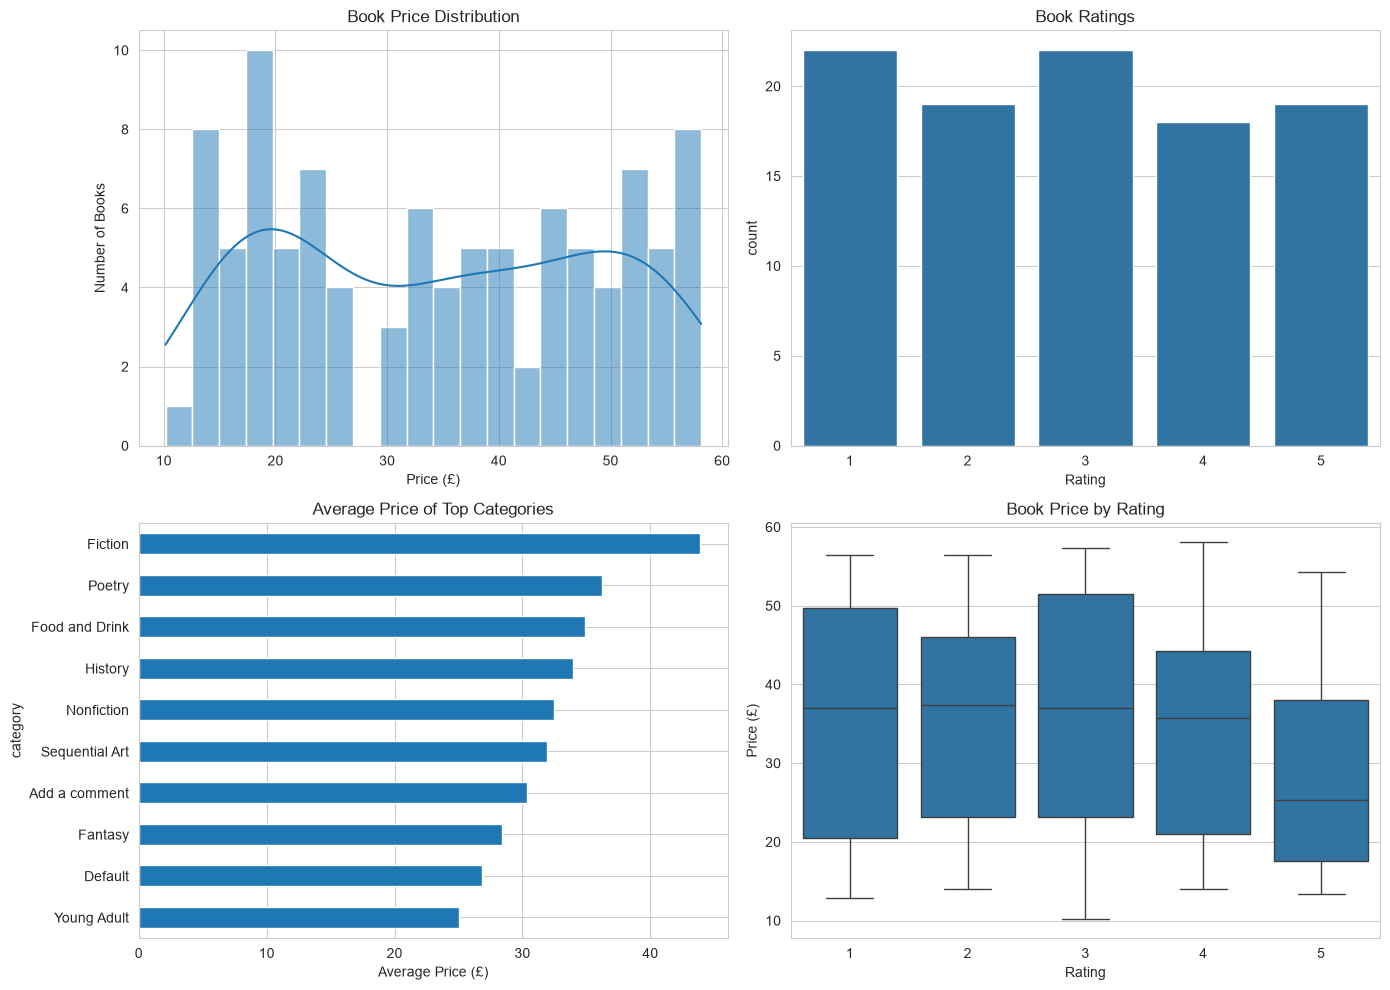

In [19]:
fig, chart_area = plt.subplots(2, 2, figsize=(14, 10))

# --- Distribution of book prices ---
sns.histplot(
    data=df,
    x="price",
    bins=20,
    kde=True,
    ax=chart_area[0, 0]
)
chart_area[0, 0].set_title("Book Price Distribution")
chart_area[0, 0].set_xlabel("Price (£)")
chart_area[0, 0].set_ylabel("Number of Books")

# --- Number of books for each rating ---
sns.countplot(
    data=df,
    x="rating",
    ax=chart_area[0, 1]
)
chart_area[0, 1].set_title("Book Ratings")
chart_area[0, 1].set_xlabel("Rating")

# --- Compare average prices across popular categories ---
popular_categories = df["category"].value_counts().head(10).index

category_prices = (
    df.loc[df["category"].isin(popular_categories)]
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=True)
)

category_prices.plot(
    kind="barh",
    ax=chart_area[1, 0]
)

chart_area[1, 0].set_title("Average Price of Top Categories")
chart_area[1, 0].set_xlabel("Average Price (£)")

# --- Compare price ranges for different ratings ---
sns.boxplot(
    data=df,
    x="rating",
    y="price",
    ax=chart_area[1, 1]
)
chart_area[1, 1].set_title("Book Price by Rating")
chart_area[1, 1].set_xlabel("Rating")
chart_area[1, 1].set_ylabel("Price (£)")

plt.tight_layout()
plt.savefig("books_analysis.png", dpi=150)
plt.show()

BOOKS COUNTS PER CATEGORY

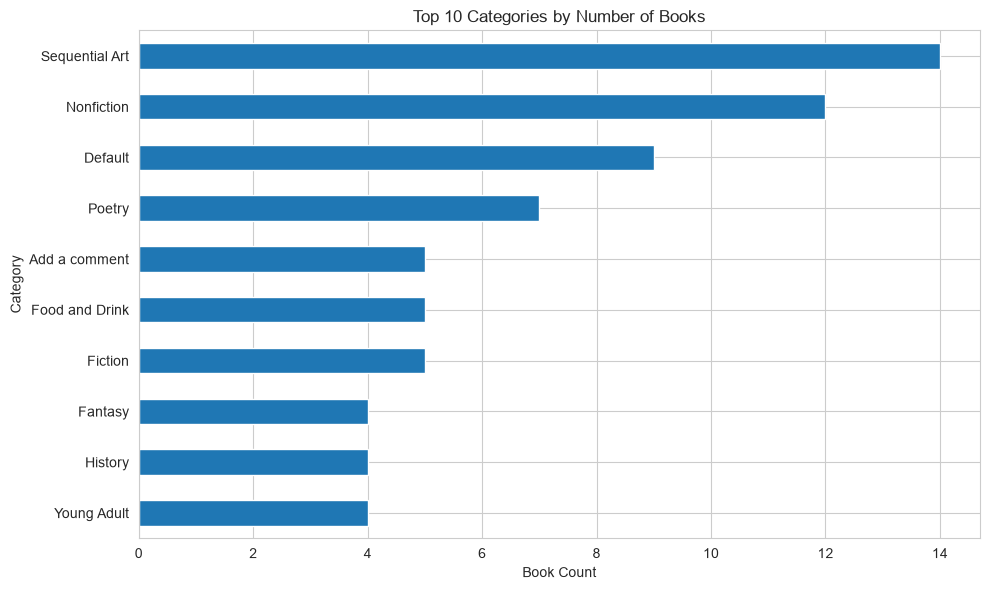

In [20]:
# --- Display the 10 categories containing the most books ---
top_categories = df["category"].value_counts().nlargest(10)

plt.figure(figsize=(10, 6))

top_categories.sort_values(ascending=True).plot(
    kind="barh"
)

plt.title("Top 10 Categories by Number of Books")
plt.xlabel("Book Count")
plt.ylabel("Category")
plt.tight_layout()

plt.savefig("top_book_categories.png", dpi=150)
plt.show()

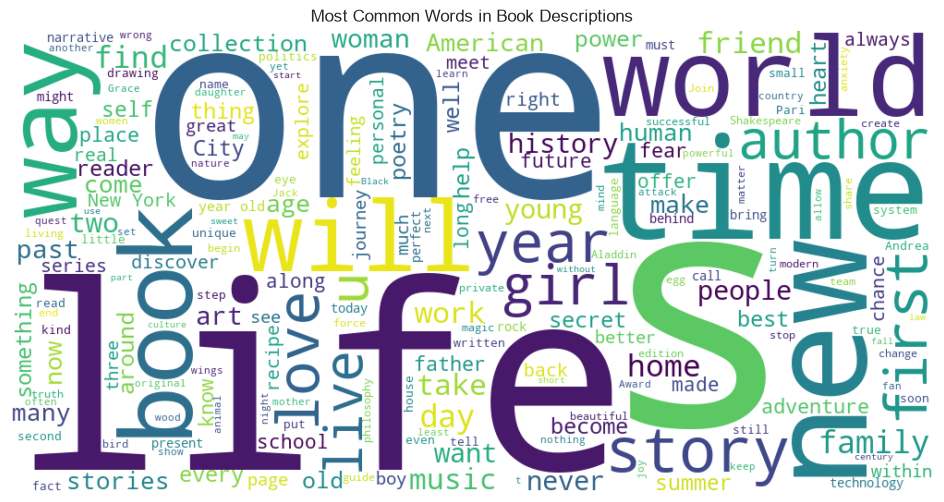

In [21]:
# --- Generate a word cloud from all book descriptions ---
description_text = " ".join(
    df["description"].fillna("").astype(str)
)

cloud_generator = WordCloud(
    width=1000,
    height=500,
    background_color="white"
)

book_wordcloud = cloud_generator.generate(description_text)

plt.figure(figsize=(12, 6))
plt.imshow(book_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Book Descriptions")

plt.savefig("book_description_wordcloud.png", dpi=150)
plt.show()

In [36]:
print("=== Summary statistics ===")
print(df[["price", "rating", "stock_count", "value_score"]].describe())

=== Summary statistics ===
            price      rating  stock_count  value_score
count  100.000000  100.000000   100.000000   100.000000
mean    34.560700    2.930000    17.180000     0.108700
std     14.638531    1.423149     1.479694     0.084838
min     10.160000    1.000000    16.000000     0.018000
25%     19.897500    2.000000    16.000000     0.051000
50%     34.775000    3.000000    16.000000     0.081000
75%     47.967500    4.000000    19.000000     0.143500
max     58.110000    5.000000    22.000000     0.375000


In [37]:
print("=== Books per category (top 10) ===")
print(df["category"].value_counts().head(10))

=== Books per category (top 10) ===
category
Sequential Art    14
Nonfiction        12
Default            9
Poetry             7
Food and Drink     5
Add a comment      5
Fiction            5
Young Adult        4
History            4
Fantasy            4
Name: count, dtype: int64


In [38]:
print("=== Highly rated books (rating = 5) ===")
print(df[df["rating"] == 5][["title", "price", "category"]].head(10))

=== Highly rated books (rating = 5) ===
                                                title  price        category
5                           Rip it Up and Start Again  35.02           Music
6   Scott Pilgrim's Precious Little Life (Scott Pi...  52.29  Sequential Art
7                                         Set Me Free  17.46     Young Adult
15              Sapiens: A Brief History of Humankind  54.23         History
21                                     Sophie's World  15.94      Philosophy
23                                  The Elephant Tree  23.82        Thriller
25  The Four Agreements: A Practical Guide to Pers...  17.66    Spirituality
27  Worlds Elsewhere: Journeys Around Shakespeare’...  40.30      Nonfiction
31                                         Black Dust  34.53         Romance
37                                             Thirst  17.27         Fiction


In [39]:
print("=== Top 10 books by value_score (best value for money) ===")
print(
    df.sort_values("value_score", ascending=False)[
        ["title", "price", "rating", "value_score", "category"]
    ].head(10)
)

=== Top 10 books by value_score (best value for money) ===
                                                title  price  rating  \
82   Princess Between Worlds (Wide-Awake Princess #5)  13.34       5   
83  Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...  13.61       5   
21                                     Sophie's World  15.94       5   
79                                           Patience  10.16       3   
37                                             Thirst  17.27       5   
7                                         Set Me Free  17.46       5   
71  Mama Tried: Traditional Italian Cooking for th...  14.02       4   
25  The Four Agreements: A Practical Guide to Pers...  17.66       5   
44            Untitled Collection: Sabbath Poems 2014  14.27       4   
78  Outcast, Vol. 1: A Darkness Surrounds Him (Out...  15.44       4   

    value_score        category  
82        0.375         Fantasy  
83        0.367  Sequential Art  
21        0.314      Philosophy  
79        0.

In [40]:
print("=== Average stock count by price band ===")
print(df.groupby("price_band")["stock_count"].mean())

=== Average stock count by price band ===
price_band
Low       16.769231
Medium    17.382353
High      17.275000
Name: stock_count, dtype: float64


In [41]:
print("=== Remaining missing values per column ===")
print(df.isna().sum())

=== Remaining missing values per column ===
title                     0
category                  0
price                     0
rating                    0
availability              0
description               0
upc                       0
num_reviews               0
product_url               0
stock_count               0
description_word_count    0
price_band                0
recommended               0
value_score               0
dtype: int64


In [42]:
df.columns

Index(['title', 'category', 'price', 'rating', 'availability', 'description',
       'upc', 'num_reviews', 'product_url', 'stock_count',
       'description_word_count', 'price_band', 'recommended', 'value_score'],
      dtype='str')

In [43]:
# --- Calculate correlation between price and rating ---
price_rating_corr = df["price"].corr(df["rating"])

print("Price vs Rating Correlation:", round(price_rating_corr, 3))

Price vs Rating Correlation: -0.122


In [44]:
# --- Find the book with the highest value score ---
best_value_book = df.loc[df["value_score"].idxmax()]

print("Best value book:")
print("Title:", best_value_book["title"])
print("Price:", best_value_book["price"])
print("Rating:", best_value_book["rating"])
print("Value score:", best_value_book["value_score"])

Best value book:
Title: Princess Between Worlds (Wide-Awake Princess #5)
Price: 13.34
Rating: 5
Value score: 0.375


In [47]:
# --- Find the group with the highest average stock ---
stock_by_rating = df.groupby("rating")["stock_count"].mean()

highest_stock_rating = stock_by_rating.idxmax()
highest_stock_value = stock_by_rating.max()

print("Rating with highest average stock:", highest_stock_rating)
print("Highest average stock:", round(highest_stock_value, 2))

Rating with highest average stock: 5
Highest average stock: 17.53


Key Observations
1. Most common category:
Sequential Art has the most books, with 14 books.

2. Highest-priced category:
Fiction has the highest average price at about £50.

3. Price vs rating:
The correlation between price and rating is , showing a weak negative relationship.

4. Most common rating:
   3 star  and 1 star books are the most common, with above 20 books.

5. Best value:
   Princess Between Worlds has the highest value score of 0.375.

6. Stock availability:
   The 5 has the highest average stock of 17.53 